# SmartGrid Demo Globale V2

Notebook **replay-first** pour :

1. charger / entraîner des runs,
2. construire un **benchmark offline** (diagnostic seulement),
3. construire un **replay benchmark** (benchmark métier officiel),
4. exécuter un **predict target day** sur un run choisi,
5. comparer **offline vs predict vs replay** sur une même date,
6. produire les **graphiques d’analyse** et le **classement final** des modèles.

### Règles du notebook

- **Référence officielle métier = replay**.
- **Offline test = diagnostic modèle / pipeline**, pas verdict final.
- Les runs comparés officiellement doivent être **homogènes** (idéalement `strict_day_ahead`).
- Le notebook ne doit **pas** réinventer la logique du repo : il orchestre les scripts et lit les artefacts.

In [17]:
from __future__ import annotations

import json
import os
import shlex
import subprocess
import sys
from pathlib import Path

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.style.use('seaborn-v0_8')

METRIC_COLUMNS = [
    'MAE', 'RMSE', 'Bias(ME)', 'MAPE%', 'SMAPE%', 'InTolerance%',
    'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%',
    'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE'
]
BASELINE_SKILL_METRICS = ['MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'RampingError_RMSE']

## 1. Configuration

Édite uniquement cette cellule pour piloter le notebook.

In [18]:
MANUAL_PROJECT_ROOT = None

DATASET_KEY = "full_2020_2026"
DATASET_OVERRIDES = {
    'historical_csv': None,
    'benchmark_csv': None,
    'weather_csv': None,
    'holidays_xlsx': None,
}

# ---------- Entraînement / benchmark offline ----------
RUN_TRAINING_BENCHMARK = False
TRAIN_CONFIGS = [
    'configs/consumption/mlp_strict_day_ahead_baseline.yaml',
    'configs/consumption/mlp_strict_day_ahead_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_shifted_dynamics.yaml',
]
TRAIN_ANALYSIS_DAYS = 1
TRAIN_ANALYSIS_DATE = None
TRAIN_PROMOTE_IMMEDIATELY = False
BENCHMARK_OUTPUT_CSV = 'artifacts/benchmarks/demo_v2_offline_benchmark.csv'
MANUAL_BENCHMARK_CSV = None

# ---------- Replay benchmark officiel ----------
RUN_REPLAY_BENCHMARK = True
REPLAY_START_DATE = '2025-11-01'
REPLAY_END_DATE = '2025-11-30'
REPLAY_MODEL_RUN_IDS = []          # si vide, le notebook choisit les meilleurs runs stricts
TOP_N_REPLAY_MODELS = 5
REPLAY_SORT_METRIC = 'MAE'
MANUAL_REPLAY_SUMMARY_CSV = None
MANUAL_REPLAY_MANIFEST_JSON = None

# ---------- Run détaillé / predict ----------
SELECTED_RUN_ID = None             # None => replay winner, sinon run_id forcé
BASELINE_RUN_ID = None             # None => meilleur baseline détecté dans l'offline benchmark
PREFERRED_SORT_METRIC = 'MAE'
OFFLINE_ONLY_STRICT = True
OFFICIAL_ONLY_STRICT = True

FORECAST_TARGET_DATE = None        # None => protocole utilise PROTOCOL_COMPARISON_DATE ou J+1 auto
FORECAST_ALLOW_FALLBACK = False

# ---------- Comparaison protocole ----------
PROTOCOL_COMPARISON_DATE = '2026-03-20'
PROTOCOL_COMPARISON_RUN_ID = None  # None => SELECTED_RUN_ID

# ---------- Plots ----------
PLOT_LAST_N_POINTS = 7 * 144
SHOW_OFFLINE_TAIL = True
SHOW_REPLAY_SUMMARY_PLOTS = True

## 2. Helpers

Les helpers ci-dessous :
- découvrent le projet,
- lisent les artefacts de runs,
- lancent les scripts du repo,
- reconstruisent des frames propres pour l’analyse.

In [19]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'smartgrid').exists():
            return candidate
    raise FileNotFoundError('Impossible de trouver la racine du projet.')

def ensure_project_on_path(project_root: Path) -> None:
    src_dir = project_root / 'src'
    if str(src_dir) not in sys.path:
        sys.path.insert(0, str(src_dir))

def first_existing(paths) -> Path | None:
    for path in paths:
        if path and Path(path).exists():
            return Path(path)
    return None

def resolve_existing_path(path_like, *bases: Path) -> Path | None:
    if not path_like:
        return None
    raw = Path(path_like).expanduser()
    candidates = [raw]
    if not raw.is_absolute():
        for base in bases:
            if base is not None:
                candidates.append(base / raw)
    return first_existing(candidates)

def load_json(path: str | Path) -> dict:
    return json.loads(Path(path).read_text(encoding='utf-8'))

def normalize_date_str(value: str | None) -> str | None:
    if value is None:
        return None
    text = str(value).strip()
    if not text or text.lower() == 'none':
        return None
    return str(pd.Timestamp(text).date())

def choose_first_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f'Aucune colonne trouvee parmi {candidates}. Colonnes: {list(df.columns)}')
    return None

def run_command(command: list[str], project_root: Path) -> str:
    env = os.environ.copy()
    env['PYTHONPATH'] = str(project_root / 'src') + (os.pathsep + env['PYTHONPATH'] if env.get('PYTHONPATH') else '')
    print('> ' + ' '.join(shlex.quote(part) for part in command))
    completed = subprocess.run(command, cwd=project_root, env=env, capture_output=True, text=True)
    if completed.stdout.strip():
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr.strip():
            print(completed.stderr)
        raise RuntimeError(f'Commande en echec code={completed.returncode}')
    return completed.stdout

def extract_last_json(stdout: str) -> dict:
    decoder = json.JSONDecoder()
    starts = [index for index, char in enumerate(stdout) if char == '{']
    for start in reversed(starts):
        snippet = stdout[start:]
        try:
            payload, end = decoder.raw_decode(snippet)
            if snippet[end:].strip() == '':
                return payload
        except json.JSONDecodeError:
            continue
    raise RuntimeError('Impossible de retrouver le JSON final dans la sortie de commande.')

def format_feature_signature(feature_cfg: dict | None) -> str:
    feature_cfg = dict(feature_cfg or {})
    parts = []
    if feature_cfg.get('include_calendar', True):
        parts.append('cal')
    if feature_cfg.get('include_temperature', False):
        parts.append('temp')
    if feature_cfg.get('include_manual_daily_lags', False):
        parts.append('lags')
    if feature_cfg.get('include_cyclical_time', False):
        parts.append('cyc')
    if feature_cfg.get('include_lag_aggregates', False):
        parts.append('lagagg')
    if feature_cfg.get('include_shifted_recent_dynamics', False):
        parts.append('shifted_dyn')
    if feature_cfg.get('include_recent_dynamics', False):
        parts.append('dyn')
    if feature_cfg.get('include_weather', False):
        parts.append(f"weather={feature_cfg.get('weather_mode', 'custom')}")
    if not feature_cfg.get('include_temperature', False) and not feature_cfg.get('include_weather', False):
        parts.append('no-weather')
    lag_days = feature_cfg.get('lag_days') or []
    if lag_days:
        parts.append('J=' + '-'.join(str(day) for day in lag_days))
    return ' | '.join(parts) if parts else 'features inconnues'

def infer_forecast_mode_from_config(config_path: str | None, config_name: str | None = None) -> str | None:
    raw = config_path or config_name
    if not raw:
        return None
    name = Path(str(raw)).name.lower()
    if 'strict_day_ahead' in name:
        return 'strict_day_ahead'
    if 'intraday_reforecast' in name or 'reforecast' in name:
        return 'intraday_reforecast'
    return None

def resolve_forecast_mode_value(raw_forecast_mode: str | None, config_path: str | None = None, config_name: str | None = None) -> str | None:
    if raw_forecast_mode:
        return str(raw_forecast_mode)
    return infer_forecast_mode_from_config(config_path, config_name)

def resolve_notebook_data_config(project_root: Path) -> dict:
    config = dict(DATASET_OVERRIDES)
    if DATASET_KEY:
        config['dataset_key'] = DATASET_KEY
    config['catalog_path'] = None
    for key in ['historical_csv', 'benchmark_csv', 'weather_csv', 'holidays_xlsx']:
        config[key] = str(resolve_existing_path(config.get(key), project_root)) if config.get(key) else None
    return config

def resolve_notebook_data_paths(project_root: Path) -> tuple[Path | None, Path | None, Path | None, Path | None]:
    cfg = resolve_notebook_data_config(project_root)
    return (
        resolve_existing_path(cfg.get('historical_csv'), project_root),
        resolve_existing_path(cfg.get('benchmark_csv'), project_root),
        resolve_existing_path(cfg.get('weather_csv'), project_root),
        resolve_existing_path(cfg.get('holidays_xlsx'), project_root),
    )

def list_available_train_configs(project_root: Path) -> list[str]:
    configs_dir = project_root / 'configs' / 'consumption'
    return [str(path.relative_to(project_root)) for path in sorted(configs_dir.glob('*.yaml'))]

def collect_runs(project_root: Path) -> pd.DataFrame:
    rows = []
    runs_dir = project_root / 'artifacts' / 'runs' / 'consumption'
    for run_summary_path in sorted(runs_dir.glob('*/run_summary.json')):
        payload = load_json(run_summary_path)
        config_path = payload.get('config_path')
        config_name = Path(config_path).name if config_path else None
        feature_config = payload.get('feature_config') or {}
        offline_metrics = dict(payload.get('offline_test_metrics') or payload.get('metrics_model') or {})
        rows.append({
            'run_id': str(payload.get('run_id', run_summary_path.parent.name)),
            'run_summary_path': str(run_summary_path.resolve()),
            'run_dir': str(run_summary_path.parent.resolve()),
            'exports_dir': payload.get('exports_dir'),
            'config_path': config_path,
            'config_name': config_name,
            'experiment_name': payload.get('experiment_name'),
            'feature_config': feature_config,
            'forecast_mode': resolve_forecast_mode_value(payload.get('forecast_mode') or feature_config.get('forecast_mode'), config_path, config_name),
            'feature_signature': format_feature_signature(feature_config),
            'n_features': payload.get('n_features'),
            'selected_analysis_day': payload.get('selected_analysis_day'),
            'is_baseline_config': bool(config_name and 'baseline' in config_name.lower()),
            **offline_metrics,
        })
    return pd.DataFrame(rows)

def current_run_id(project_root: Path) -> str | None:
    current_summary = first_existing([
        project_root / 'artifacts' / 'models' / 'consumption' / 'current' / 'run_summary.json',
        project_root / 'artifacts' / 'models' / 'consumption' / 'current' / 'summary.json',
    ])
    if current_summary is None:
        return None
    payload = load_json(current_summary)
    return str(payload.get('run_id')) if payload.get('run_id') else None

def payloads_to_benchmark_df(payloads: list[dict], catalog_df: pd.DataFrame | None = None) -> pd.DataFrame:
    rows = []
    for payload in payloads:
        metrics = dict(payload.get('offline_test_metrics') or payload.get('metrics_model') or {})
        rows.append({
            'config_name': Path(str(payload.get('config'))).name if payload.get('config') else None,
            'run_id': payload.get('run_id'),
            'run_dir': payload.get('run_dir'),
            'exports_dir': payload.get('exports_dir'),
            'experiment_name': payload.get('experiment_name'),
            'selected_analysis_day': payload.get('selected_analysis_day'),
            'train_duration_sec': payload.get('train_duration_sec'),
            'n_features': payload.get('n_features'),
            'epochs_ran': payload.get('epochs_ran'),
            'best_val_loss': payload.get('best_val_loss'),
            'final_train_loss': payload.get('final_train_loss'),
            'final_val_loss': payload.get('final_val_loss'),
            'n_train_rows': payload.get('n_train_rows'),
            'n_val_rows': payload.get('n_val_rows'),
            'n_test_rows': payload.get('n_test_rows'),
            'forecast_mode': resolve_forecast_mode_value(payload.get('forecast_mode'), payload.get('config'), Path(str(payload.get('config'))).name if payload.get('config') else None),
            'feature_config_json': json.dumps(payload.get('feature_config'), sort_keys=True),
            **metrics,
        })
    out = pd.DataFrame(rows)
    if catalog_df is not None and not out.empty and not catalog_df.empty:
        meta = catalog_df[['run_id', 'config_name', 'feature_signature', 'forecast_mode']].drop_duplicates()
        out = out.merge(meta, on='run_id', how='left', suffixes=('', '_meta'))
        if 'config_name_meta' in out.columns:
            out['config_name'] = out['config_name'].fillna(out['config_name_meta'])
            out = out.drop(columns=['config_name_meta'])
    if not out.empty and 'config_name' in out.columns:
        out['config_stem'] = out['config_name'].map(lambda value: Path(str(value)).stem if pd.notna(value) else None)
    return out

def build_benchmark_df_from_catalog(catalog_df: pd.DataFrame) -> pd.DataFrame:
    if catalog_df.empty:
        return pd.DataFrame()
    rows = []
    for _, row in catalog_df.iterrows():
        payload = load_json(row['run_summary_path'])
        metrics = dict(payload.get('offline_test_metrics') or payload.get('metrics_model') or {})
        config_path = payload.get('config_path')
        rows.append({
            'config_name': Path(str(config_path)).name if config_path else row.get('config_name'),
            'run_id': payload.get('run_id') or row.get('run_id'),
            'run_dir': payload.get('run_dir') or row.get('run_dir'),
            'exports_dir': payload.get('exports_dir') or row.get('exports_dir'),
            'experiment_name': payload.get('experiment_name') or row.get('experiment_name'),
            'selected_analysis_day': payload.get('selected_analysis_day'),
            'train_duration_sec': payload.get('train_duration_sec'),
            'n_features': payload.get('n_features'),
            'epochs_ran': payload.get('epochs_ran'),
            'best_val_loss': payload.get('best_val_loss'),
            'final_train_loss': payload.get('final_train_loss'),
            'final_val_loss': payload.get('final_val_loss'),
            'n_train_rows': payload.get('n_train_rows'),
            'n_val_rows': payload.get('n_val_rows'),
            'n_test_rows': payload.get('n_test_rows'),
            'forecast_mode': resolve_forecast_mode_value(payload.get('forecast_mode'), config_path, row.get('config_name')),
            'feature_signature': row.get('feature_signature'),
            **metrics,
        })
    out = pd.DataFrame(rows)
    if not out.empty and 'config_name' in out.columns:
        out['config_stem'] = out['config_name'].map(lambda value: Path(str(value)).stem if pd.notna(value) else None)
    return out

def add_baseline_comparison(df: pd.DataFrame, baseline_run_id: str | None) -> pd.DataFrame:
    out = df.copy()
    for metric in BASELINE_SKILL_METRICS:
        if metric in out.columns:
            out[f'{metric}_delta_vs_baseline'] = np.nan
            out[f'{metric}_skill_vs_baseline_%'] = np.nan
    if 'InTolerance%' in out.columns:
        out['InTolerance_delta_vs_baseline'] = np.nan
    if not baseline_run_id or out.empty or baseline_run_id not in out['run_id'].astype(str).tolist():
        return out
    baseline_row = out[out['run_id'].astype(str) == str(baseline_run_id)].iloc[0]
    for metric in BASELINE_SKILL_METRICS:
        if metric in out.columns:
            out[f'{metric}_delta_vs_baseline'] = out[metric] - baseline_row[metric]
            if baseline_row[metric] not in [0, None] and pd.notna(baseline_row[metric]):
                out[f'{metric}_skill_vs_baseline_%'] = 100 * (1 - out[metric] / baseline_row[metric])
    if 'InTolerance%' in out.columns and pd.notna(baseline_row.get('InTolerance%')):
        out['InTolerance_delta_vs_baseline'] = out['InTolerance%'] - baseline_row['InTolerance%']
    return out

def resolve_baseline_run_id(bench: pd.DataFrame) -> str | None:
    if BASELINE_RUN_ID:
        return str(BASELINE_RUN_ID)
    if bench.empty or 'config_name' not in bench.columns:
        return None
    baseline_mask = bench['config_name'].astype(str).str.contains('baseline', case=False, na=False)
    if OFFLINE_ONLY_STRICT and 'forecast_mode' in bench.columns:
        baseline_mask = baseline_mask & (bench['forecast_mode'].fillna('').astype(str) == 'strict_day_ahead')
    if not baseline_mask.any():
        return None
    sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in bench.columns]
    return str(bench.loc[baseline_mask].sort_values(sort_cols or ['run_id']).iloc[0]['run_id'])

def resolve_selected_run_id(replay_df: pd.DataFrame, offline_df: pd.DataFrame, current_run: str | None) -> str | None:
    if SELECTED_RUN_ID:
        return str(SELECTED_RUN_ID)
    if not replay_df.empty and 'requested_model_run_id' in replay_df.columns:
        sort_cols = [col for col in [REPLAY_SORT_METRIC, 'RMSE', 'MAE'] if col in replay_df.columns]
        ordered = replay_df.dropna(subset=sort_cols[:1]).sort_values(sort_cols or ['requested_model_run_id'])
        if not ordered.empty:
            return str(ordered.iloc[0]['requested_model_run_id'])
    if not offline_df.empty and 'run_id' in offline_df.columns:
        sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in offline_df.columns]
        ordered = offline_df.dropna(subset=sort_cols[:1]).sort_values(sort_cols or ['run_id'])
        if not ordered.empty:
            return str(ordered.iloc[0]['run_id'])
    return current_run

def resolve_run_summary_path(project_root: Path, run_id: str) -> Path | None:
    return first_existing([
        project_root / 'artifacts' / 'runs' / 'consumption' / str(run_id) / 'run_summary.json',
        project_root / 'artifacts' / 'runs' / 'consumption' / str(run_id) / 'summary.json',
    ])

def resolve_run_artifacts(project_root: Path, run_id: str) -> dict:
    summary_path = resolve_run_summary_path(project_root, run_id)
    if summary_path is None:
        raise FileNotFoundError(f'run_summary introuvable pour {run_id}')
    summary = load_json(summary_path)
    run_dir = resolve_existing_path(summary.get('run_dir'), project_root, summary_path.parent) or summary_path.parent
    exports_dir = first_existing([
        resolve_existing_path(summary.get('exports_dir'), project_root, run_dir, summary_path.parent),
        project_root / 'artifacts' / 'exports' / 'consumption' / str(run_id),
        run_dir,
    ])
    offline_backtest_csv = first_existing([
        resolve_existing_path(summary.get('offline_test_backtest_csv'), project_root, run_dir, exports_dir),
        resolve_existing_path(summary.get('backtest_csv'), project_root, run_dir, exports_dir),
        run_dir / 'offline_test_backtest.csv',
        run_dir / 'backtest.csv',
        exports_dir / 'offline_test_backtest.csv' if exports_dir else None,
        exports_dir / 'backtest.csv' if exports_dir else None,
    ])
    offline_selected_day_csv = first_existing([
        resolve_existing_path(summary.get('offline_test_selected_day_csv'), project_root, run_dir, exports_dir),
        resolve_existing_path(summary.get('day_compare_csv'), project_root, run_dir, exports_dir),
    ])
    return {
        'summary_path': summary_path,
        'summary': summary,
        'run_dir': run_dir,
        'exports_dir': exports_dir,
        'offline_backtest_csv': offline_backtest_csv,
        'offline_selected_day_csv': offline_selected_day_csv,
    }

def resolve_run_data_inputs(project_root: Path, run_id: str) -> tuple[Path | None, Path | None, Path | None]:
    historical_csv, _, weather_csv, holidays_xlsx = resolve_notebook_data_paths(project_root)
    if historical_csv is not None:
        return historical_csv, weather_csv, holidays_xlsx
    summary_path = resolve_run_summary_path(project_root, run_id)
    if summary_path is None:
        return None, None, None
    payload = load_json(summary_path)
    return (
        resolve_existing_path(payload.get('historical_csv'), project_root),
        resolve_existing_path(payload.get('weather_csv'), project_root),
        resolve_existing_path(payload.get('holidays_xlsx'), project_root),
    )

def resolve_run_forecast_mode(project_root: Path, run_id: str) -> str | None:
    summary_path = resolve_run_summary_path(project_root, run_id)
    if summary_path is None:
        return None
    payload = load_json(summary_path)
    feature_config = payload.get('feature_config') or {}
    config_path = payload.get('config_path')
    config_name = Path(str(config_path)).name if config_path else None
    forecast_mode = resolve_forecast_mode_value(payload.get('forecast_mode') or feature_config.get('forecast_mode'), config_path, config_name)
    return str(forecast_mode) if forecast_mode else None

def filter_strict_replay_run_ids(project_root: Path, run_ids: list[str]) -> tuple[list[str], list[str]]:
    selected = []
    excluded = []
    for raw_run_id in run_ids:
        run_id = str(raw_run_id)
        forecast_mode = resolve_run_forecast_mode(project_root, run_id)
        if forecast_mode != 'strict_day_ahead':
            excluded.append(run_id)
            continue
        if run_id not in selected:
            selected.append(run_id)
    return selected, excluded

def train_config(project_root: Path, config_path: str) -> dict:
    data_cfg = resolve_notebook_data_config(project_root)
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'train_consumption.py'),
        '--config', str(resolve_existing_path(config_path, project_root) or config_path),
        '--analysis-days', str(TRAIN_ANALYSIS_DAYS),
    ]
    if data_cfg.get('dataset_key'):
        command.extend(['--dataset-key', str(data_cfg['dataset_key'])])
    if data_cfg.get('catalog_path'):
        command.extend(['--catalog-path', str(data_cfg['catalog_path'])])
    for arg_name, key in [
        ('--historical-csv', 'historical_csv'),
        ('--benchmark-csv', 'benchmark_csv'),
        ('--weather-csv', 'weather_csv'),
        ('--holidays-xlsx', 'holidays_xlsx'),
    ]:
        if data_cfg.get(key):
            command.extend([arg_name, str(data_cfg[key])])
    if TRAIN_ANALYSIS_DATE:
        command.extend(['--analysis-date', str(TRAIN_ANALYSIS_DATE)])
    if TRAIN_PROMOTE_IMMEDIATELY:
        command.append('--promote')
    return extract_last_json(run_command(command, project_root))

def run_replay_benchmark(project_root: Path, model_run_ids: list[str], reference_run_id: str | None) -> tuple[Path | None, Path | None]:
    if not model_run_ids or not reference_run_id:
        return None, None
    historical_csv, weather_csv, holidays_xlsx = resolve_run_data_inputs(project_root, reference_run_id)
    if historical_csv is None:
        raise FileNotFoundError(f'Impossible de resoudre historical_csv pour le replay de {reference_run_id}')
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'benchmark_replay_models.py'),
        '--historical-csv', str(historical_csv),
        '--start-date', str(REPLAY_START_DATE),
        '--end-date', str(REPLAY_END_DATE),
        '--artifacts-root', str(project_root / 'artifacts'),
        '--device', 'auto',
    ]
    if weather_csv is not None:
        command.extend(['--weather-csv', str(weather_csv)])
    if holidays_xlsx is not None:
        command.extend(['--holidays-xlsx', str(holidays_xlsx)])
    command.extend(str(run_id) for run_id in model_run_ids)
    payload = extract_last_json(run_command(command, project_root))
    summary_csv = Path(payload['summary_csv']).resolve()
    manifest_json = Path(payload['manifest_json']).resolve() if payload.get('manifest_json') else None
    return summary_csv, manifest_json

def load_replay_results(summary_csv: Path, catalog_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_df = pd.read_csv(summary_csv).copy()
    summary_df.columns = [str(col).strip() for col in summary_df.columns]
    if 'requested_model_run_id' not in summary_df.columns and 'run_id' in summary_df.columns:
        summary_df = summary_df.rename(columns={'run_id': 'requested_model_run_id'})
    meta = catalog_df.rename(columns={'run_id': 'requested_model_run_id'}).copy() if not catalog_df.empty else pd.DataFrame()
    if not meta.empty:
        keep_cols = [col for col in ['requested_model_run_id', 'config_name', 'feature_signature', 'forecast_mode', 'n_features'] if col in meta.columns]
        summary_df = summary_df.merge(meta[keep_cols], on='requested_model_run_id', how='left')
    for metric in METRIC_COLUMNS + ['count', 'n_requested_days', 'n_forecasted_days', 'n_skipped_days']:
        if metric in summary_df.columns:
            summary_df[metric] = pd.to_numeric(summary_df[metric], errors='coerce')

    replay_frames = []
    per_day_frames = []
    for _, row in summary_df.iterrows():
        replay_csv = row.get('replay_csv')
        metrics_json = row.get('metrics_json')
        if pd.notna(replay_csv) and replay_csv and Path(replay_csv).exists():
            replay_df = pd.read_csv(replay_csv)
            replay_df['Date'] = pd.to_datetime(replay_df['Date'], errors='coerce')
            replay_df['requested_model_run_id'] = str(row['requested_model_run_id'])
            replay_frames.append(replay_df)
        if pd.notna(metrics_json) and metrics_json and Path(metrics_json).exists():
            payload = load_json(metrics_json)
            day_df = pd.DataFrame(payload.get('per_day_metrics', []))
            if not day_df.empty:
                day_df['requested_model_run_id'] = str(payload.get('requested_model_run_id', row['requested_model_run_id']))
                per_day_frames.append(day_df)

    replay_all_df = pd.concat(replay_frames, ignore_index=True) if replay_frames else pd.DataFrame()
    replay_per_day_df = pd.concat(per_day_frames, ignore_index=True) if per_day_frames else pd.DataFrame()
    return summary_df, replay_all_df, replay_per_day_df

def load_history_total(history_csv: Path) -> pd.Series:
    from smartgrid.data.loaders import load_history
    hist = load_history(history_csv)
    return hist.set_index('Date')['tot'].sort_index()

def compute_weekly_naive_for_dates(dates: pd.Series, hist_total: pd.Series) -> pd.Series:
    return pd.to_datetime(dates).map(lambda ts: hist_total.get(pd.Timestamp(ts) - pd.Timedelta(days=7)))

def compute_metrics(real: pd.Series, pred: pd.Series) -> dict:
    mask = real.notna() & pred.notna()
    y = real[mask].astype(float)
    yhat = pred[mask].astype(float)
    if len(y) == 0:
        return {'count': 0}
    err = yhat - y
    abs_err = err.abs()
    ape = abs_err / y.replace(0, np.nan).abs()
    smape = abs_err / ((y.abs() + yhat.abs()) / 2).replace(0, np.nan)
    tol = np.maximum(0.01 * y.abs(), 5000.0)
    ramp = (yhat.diff() - y.diff()).dropna()
    return {
        'count': int(mask.sum()),
        'MAE': float(abs_err.mean()),
        'RMSE': float(np.sqrt((err ** 2).mean())),
        'Bias(ME)': float(err.mean()),
        'MAPE%': float(100 * ape.dropna().mean()) if ape.dropna().size else np.nan,
        'SMAPE%': float(100 * smape.dropna().mean()) if smape.dropna().size else np.nan,
        'InTolerance%': float(100 * (abs_err <= tol).mean()),
        'P95AbsError': float(abs_err.quantile(0.95)),
        'P99AbsError': float(abs_err.quantile(0.99)),
        'UnderShare%': float(100 * (err < 0).mean()),
        'OverShare%': float(100 * (err > 0).mean()),
        'Under_MAE': float(abs_err[err < 0].mean()) if (err < 0).any() else np.nan,
        'Over_MAE': float(abs_err[err > 0].mean()) if (err > 0).any() else np.nan,
        'CorrAbsErr_vs_Real': float(abs_err.corr(y)) if len(y) > 1 else np.nan,
        'RampingError_RMSE': float(np.sqrt((ramp ** 2).mean())) if len(ramp) > 0 else np.nan,
    }

def infer_cols(df: pd.DataFrame):
    date_col = choose_first_col(df, ['Date', 'date', 'timestamp'])
    real_col = choose_first_col(df, ['Ptot_TOTAL_Real', 'Ptot_TOTAL', 'tot', 'actual', 'y_true'])
    pred_col = choose_first_col(df, ['Ptot_TOTAL_Forecast', 'forecast', 'prediction', 'y_pred'])
    legacy_col = choose_first_col(df, ['OldLegacy_TOTAL_Forecast', 'old_legacy_forecast', 'legacy_forecast'], required=False)
    baseline_col = choose_first_col(df, ['NaiveWeekly_Forecast', 'Baseline_Forecast', 'weekly_naive_forecast', 'lag_d7'], required=False)
    return date_col, real_col, pred_col, legacy_col, baseline_col

def extract_day_from_backtest_frame(backtest: pd.DataFrame, target_date: str | None, history_csv: Path | None = None) -> pd.DataFrame:
    target_date = normalize_date_str(target_date)
    if backtest.empty or target_date is None:
        return pd.DataFrame()
    out = backtest.copy()
    out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    out = out.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    out = out[out['Date'].dt.date == pd.to_datetime(target_date).date()].copy()
    if out.empty:
        return out
    if 'BASELINE_WEEKLY' not in out.columns and history_csv is not None:
        hist_total = load_history_total(history_csv)
        out['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(out['Date'], hist_total)
    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY'] if col in out.columns]
    return out[keep_cols].reset_index(drop=True)

def forecast_run_for_target_day(project_root: Path, run_id: str, target_date: str) -> pd.DataFrame:
    import smartgrid.features.engineering as engineering_module
    import smartgrid.inference.day_ahead as day_ahead_module
    engineering_module = importlib.reload(engineering_module)
    day_ahead_module = importlib.reload(day_ahead_module)
    build_forecast_runtime = day_ahead_module.build_forecast_runtime
    forecast_target_day = day_ahead_module.forecast_target_day
    artifacts = resolve_run_artifacts(project_root, run_id)
    historical_csv, weather_csv, holidays_xlsx = resolve_run_data_inputs(project_root, run_id)
    _, benchmark_csv, _, _ = resolve_notebook_data_paths(project_root)
    runtime = build_forecast_runtime(
        historical_csv=historical_csv,
        current_dir=artifacts['run_dir'],
        artifacts_root=project_root / 'artifacts',
        weather_csv=weather_csv,
        holidays_xlsx=holidays_xlsx,
        benchmark_csv=benchmark_csv,
        device_request='auto',
        allow_fallback=FORECAST_ALLOW_FALLBACK,
    )
    return forecast_target_day(runtime, str(pd.Timestamp(target_date).date()))

def build_requested_day_frame(project_root: Path, run_id: str, target_date: str, history_csv: Path | None = None) -> pd.DataFrame:
    from smartgrid.data.loaders import load_old_benchmark
    target_date = str(pd.Timestamp(target_date).date())
    forecast_df = forecast_run_for_target_day(project_root, run_id, target_date)
    if forecast_df.empty:
        return pd.DataFrame()
    day_df = forecast_df.rename(columns={'Ptot_TOTAL_Forecast': 'MODEL', 'Ptot_TOTAL_Real': 'REAL'}).copy()
    day_df['Date'] = pd.to_datetime(day_df['Date'], errors='coerce')
    day_df = day_df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    if history_csv is not None:
        hist_total = load_history_total(history_csv)
        day_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(day_df['Date'], hist_total)
    _, benchmark_csv, _, _ = resolve_notebook_data_paths(project_root)
    old_legacy_df = load_old_benchmark(benchmark_csv) if benchmark_csv is not None else None
    if old_legacy_df is not None and not old_legacy_df.empty:
        old_legacy_df['Date'] = pd.to_datetime(old_legacy_df['Date'], errors='coerce')
        old_legacy_df = old_legacy_df.rename(columns={'OldLegacy_TOTAL_Forecast': 'OLD_LEGACY'})
        day_df = day_df.merge(old_legacy_df[['Date', 'OLD_LEGACY']].drop_duplicates(subset=['Date']), on='Date', how='left')
    return day_df

def load_prepared_run_frames(project_root: Path, run_id: str, history_csv: Path | None = None, requested_day: str | None = None) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    artifacts = resolve_run_artifacts(project_root, run_id)
    summary = dict(artifacts['summary'])
    backtest_csv = artifacts['offline_backtest_csv']
    if backtest_csv is None:
        day_df = build_requested_day_frame(project_root, run_id, requested_day, history_csv=history_csv) if requested_day else pd.DataFrame()
        if requested_day:
            summary['selected_analysis_day'] = str(pd.Timestamp(requested_day).date())
        return summary, pd.DataFrame(), day_df
    backtest = pd.read_csv(backtest_csv)
    date_col, real_col, pred_col, legacy_col, baseline_col = infer_cols(backtest)
    backtest[date_col] = pd.to_datetime(backtest[date_col], errors='coerce')
    backtest = backtest.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    renamed = backtest.rename(columns={date_col: 'Date', real_col: 'REAL', pred_col: 'MODEL'}).copy()
    if legacy_col is not None and legacy_col in renamed.columns:
        renamed = renamed.rename(columns={legacy_col: 'OLD_LEGACY'})
    if baseline_col is not None and baseline_col in renamed.columns and baseline_col != 'lag_d7':
        renamed = renamed.rename(columns={baseline_col: 'BASELINE_WEEKLY'})
    if 'BASELINE_WEEKLY' not in renamed.columns and history_csv is not None:
        hist_total = load_history_total(history_csv)
        renamed['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(renamed['Date'], hist_total)
    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY'] if col in renamed.columns]
    backtest_prepared = renamed[keep_cols].copy()
    target_day = requested_day or summary.get('selected_analysis_day')
    day_df = extract_day_from_backtest_frame(backtest_prepared, target_day, history_csv=history_csv)
    if target_day:
        summary['selected_analysis_day'] = str(pd.Timestamp(target_day).date())
    return summary, backtest_prepared, day_df

def build_replay_requested_day_frame(replay_all_df: pd.DataFrame, run_id: str, target_date: str, history_csv: Path | None = None) -> pd.DataFrame:
    target_date = normalize_date_str(target_date)
    if replay_all_df.empty or target_date is None:
        return pd.DataFrame()
    work = replay_all_df.copy()
    if 'requested_model_run_id' in work.columns:
        work['requested_model_run_id'] = work['requested_model_run_id'].astype(str)
        work = work[work['requested_model_run_id'] == str(run_id)].copy()
    work['target_date'] = pd.to_datetime(work['target_date'], errors='coerce').dt.date.astype(str)
    work['Date'] = pd.to_datetime(work['Date'], errors='coerce')
    work = work[work['target_date'] == target_date].copy()
    if work.empty:
        return pd.DataFrame()
    day_df = work.rename(columns={'Ptot_TOTAL_Real': 'REAL', 'Ptot_TOTAL_Forecast': 'MODEL'}).copy()
    if history_csv is not None:
        hist_total = load_history_total(history_csv)
        day_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(day_df['Date'], hist_total)
    _, benchmark_csv, _, _ = resolve_notebook_data_paths(PROJECT_ROOT)
    if benchmark_csv is not None:
        from smartgrid.data.loaders import load_old_benchmark
        legacy = load_old_benchmark(benchmark_csv)
        if legacy is not None and not legacy.empty:
            legacy['Date'] = pd.to_datetime(legacy['Date'], errors='coerce')
            legacy = legacy.rename(columns={'OldLegacy_TOTAL_Forecast': 'OLD_LEGACY'})
            day_df = day_df.merge(legacy[['Date', 'OLD_LEGACY']].drop_duplicates(subset=['Date']), on='Date', how='left')
    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY', 'model_run_id'] if col in day_df.columns]
    return day_df[keep_cols].sort_values('Date').reset_index(drop=True)

def prepare_protocol_frame(day_df: pd.DataFrame, protocol_name: str, target_date: str, run_id: str, effective_model_run_ids: str | None = None) -> pd.DataFrame:
    if day_df is None or day_df.empty:
        return pd.DataFrame()
    out = day_df.copy()
    out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    out = out.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY'] if col in out.columns]
    out = out[keep_cols].copy()
    out['protocol'] = protocol_name
    out['run_id'] = str(run_id)
    out['target_date'] = normalize_date_str(target_date)
    out['effective_model_run_ids'] = effective_model_run_ids or str(run_id)
    return out

def summarize_protocol_metrics(protocol_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for protocol_name, frame in protocol_frames.items():
        if frame is None or frame.empty:
            continue
        row = {
            'protocol': protocol_name,
            'target_date': frame['target_date'].iloc[0] if 'target_date' in frame.columns else None,
            'run_id': frame['run_id'].iloc[0] if 'run_id' in frame.columns else None,
            'effective_model_run_ids': frame['effective_model_run_ids'].iloc[0] if 'effective_model_run_ids' in frame.columns else None,
        }
        row.update(compute_metrics(frame['REAL'], frame['MODEL']))
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows)
    sort_cols = [col for col in ['RMSE', 'MAE'] if col in out.columns]
    return out.sort_values(sort_cols or ['protocol']).reset_index(drop=True)

def compare_protocol_predictions(protocol_frames: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    normalized = {}
    for protocol_name, frame in protocol_frames.items():
        if frame is None or frame.empty:
            continue
        normalized[protocol_name] = frame[['Date', 'MODEL']].drop_duplicates(subset=['Date']).rename(columns={'MODEL': protocol_name})
    if len(normalized) < 2:
        return pd.DataFrame(), pd.DataFrame()
    merged = None
    for protocol_name, frame in normalized.items():
        merged = frame if merged is None else merged.merge(frame, on='Date', how='outer')
    protocols = list(normalized.keys())
    reference_protocol = 'benchmark_test_day' if 'benchmark_test_day' in protocols else protocols[0]
    delta_rows = []
    for protocol_name in protocols:
        if protocol_name == reference_protocol:
            continue
        overlap_mask = merged[[reference_protocol, protocol_name]].notna().all(axis=1)
        if not overlap_mask.any():
            delta_rows.append({'reference_protocol': reference_protocol, 'compared_protocol': protocol_name, 'overlap_count': 0, 'mean_abs_prediction_delta': np.nan, 'max_abs_prediction_delta': np.nan})
            continue
        diff = (merged.loc[overlap_mask, protocol_name] - merged.loc[overlap_mask, reference_protocol]).abs()
        delta_rows.append({
            'reference_protocol': reference_protocol,
            'compared_protocol': protocol_name,
            'overlap_count': int(overlap_mask.sum()),
            'mean_abs_prediction_delta': float(diff.mean()),
            'max_abs_prediction_delta': float(diff.max()),
        })
    return merged.sort_values('Date').reset_index(drop=True), pd.DataFrame(delta_rows)

def plot_day_curves(day_df: pd.DataFrame, title: str) -> None:
    if day_df is None or day_df.empty:
        print(f'Aucune donnee pour {title}')
        return
    plt.figure(figsize=(18, 6))
    plt.plot(day_df['Date'], day_df['REAL'], label='REAL', color='black', linewidth=2)
    if 'MODEL' in day_df.columns:
        plt.plot(day_df['Date'], day_df['MODEL'], label='MODEL', linewidth=2)
    if 'BASELINE_WEEKLY' in day_df.columns:
        plt.plot(day_df['Date'], day_df['BASELINE_WEEKLY'], label='BASELINE_WEEKLY')
    if 'OLD_LEGACY' in day_df.columns:
        plt.plot(day_df['Date'], day_df['OLD_LEGACY'], label='OLD_LEGACY')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_error_box(frame: pd.DataFrame, title: str) -> None:
    if frame is None or frame.empty:
        return
    err_df = pd.DataFrame()
    for col in ['MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY']:
        if col in frame.columns:
            err_df[col] = (frame[col] - frame['REAL']).abs()
    if err_df.empty:
        return
    err_df.plot(kind='box', figsize=(12, 5), title=title)
    plt.tight_layout()
    plt.show()

## 3. Bootstrap projet et imports repo

In [20]:
PROJECT_ROOT = Path(MANUAL_PROJECT_ROOT).resolve() if MANUAL_PROJECT_ROOT else find_project_root()
ensure_project_on_path(PROJECT_ROOT)

from IPython.display import display
from smartgrid.data.loaders import load_old_benchmark

CATALOG_DF = collect_runs(PROJECT_ROOT)
CURRENT_RUN_ID = current_run_id(PROJECT_ROOT)
NOTEBOOK_DATA_CONFIG = resolve_notebook_data_config(PROJECT_ROOT)
HISTORICAL_CSV, BENCHMARK_CSV, WEATHER_CSV, HOLIDAYS_XLSX = resolve_notebook_data_paths(PROJECT_ROOT)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CURRENT_RUN_ID =', CURRENT_RUN_ID)
print('RUNS_FOUND =', len(CATALOG_DF))
print('DATA_CONFIG =', NOTEBOOK_DATA_CONFIG)

PROJECT_ROOT = /home/khalid/cours/m1/SmartGrid_Project/smart-grid
CURRENT_RUN_ID = consumption_mlp_20260419T180417Z
RUNS_FOUND = 53
DATA_CONFIG = {'historical_csv': None, 'benchmark_csv': None, 'weather_csv': None, 'holidays_xlsx': None, 'dataset_key': 'full_2020_2026', 'catalog_path': None}


## 4. Catalogue des runs existants

In [21]:
if CATALOG_DF.empty:
    print('Aucun run detecte dans artifacts/runs/consumption.')
else:
    catalog_view_cols = [col for col in ['run_id', 'config_name', 'forecast_mode', 'feature_signature', 'n_features', 'selected_analysis_day', 'MAE', 'RMSE'] if col in CATALOG_DF.columns]
    display(CATALOG_DF[catalog_view_cols].sort_values([col for col in ['MAE', 'RMSE'] if col in catalog_view_cols], ascending=True))

,run_id,config_name,forecast_mode,feature_signature,n_features,selected_analysis_day,MAE,RMSE
33,consumption_mlp_20260416T034047Z,mlp_cyclical_weather_dynamics_all.yaml,intraday_reforecast,cal | temp | lags | cyc | lagagg | dyn | weath...,38,2026-03-20,"4,844.271889","6,640.352289"
40,consumption_mlp_20260416T040210Z,mlp_cyclical_weather_dynamics_all.yaml,intraday_reforecast,cal | temp | lags | cyc | lagagg | dyn | weath...,38,2026-03-20,"4,844.271889","6,640.352289"
32,consumption_mlp_20260416T033944Z,mlp_cyclical_weather_dynamics.yaml,intraday_reforecast,cal | temp | lags | cyc | dyn | weather=basic ...,28,2026-03-20,"4,973.884280","6,793.901629"
39,consumption_mlp_20260416T040109Z,mlp_cyclical_weather_dynamics.yaml,intraday_reforecast,cal | temp | lags | cyc | dyn | weather=basic ...,28,2026-03-20,"4,973.884280","6,793.901629"
6,consumption_mlp_20260415T234028Z,mlp_cyclical_weather_dynamics_all.yaml,NaN,cal | temp | lags | cyc | lagagg | dyn | weath...,38,2026-03-20,"5,205.243691","7,006.030791"
17,consumption_mlp_20260416T004318Z,mlp_cyclical_weather_dynamics_all.yaml,NaN,cal | temp | lags | cyc | lagagg | dyn | weath...,38,2026-03-20,"5,205.243691","7,006.030791"
26,consumption_mlp_20260416T030250Z,mlp_cyclical_weather_dynamics_all.yaml,intraday_reforecast,cal | temp | lags | cyc | lagagg | dyn | weath...,38,2026-03-20,"5,205.243691","7,006.030791"
5,consumption_mlp_20260415T233924Z,mlp_cyclical_weather_dynamics.yaml,NaN,cal | temp | lags | cyc | dyn | weather=basic ...,28,2026-03-20,"5,237.433253","7,032.799557"
16,consumption_mlp_20260416T004215Z,mlp_cyclical_weather_dynamics.yaml,NaN,cal | temp | lags | cyc | dyn | weather=basic ...,28,2026-03-20,"5,237.433253","7,032.799557"
25,consumption_mlp_20260416T030148Z,mlp_cyclical_weather_dynamics.yaml,intraday_reforecast,cal | temp | lags | cyc | dyn | weather=basic ...,28,2026-03-20,"5,237.433253","7,032.799557"


## 5. Benchmark offline (diagnostic)

Cette section :
- entraîne les configs si demandé,
- sinon reconstruit un benchmark offline à partir des `run_summary.json`,
- classe les runs selon les métriques offline.

> Ce benchmark n'est **pas** la vérité métier officielle.

In [22]:
train_payloads = []
if RUN_TRAINING_BENCHMARK:
    for config_path in TRAIN_CONFIGS:
        train_payloads.append(train_config(PROJECT_ROOT, config_path))
    CATALOG_DF = collect_runs(PROJECT_ROOT)

if MANUAL_BENCHMARK_CSV and resolve_existing_path(MANUAL_BENCHMARK_CSV, PROJECT_ROOT):
    OFFLINE_BENCHMARK_DF = pd.read_csv(resolve_existing_path(MANUAL_BENCHMARK_CSV, PROJECT_ROOT))
    if 'config_name' not in OFFLINE_BENCHMARK_DF.columns and 'config' in OFFLINE_BENCHMARK_DF.columns:
        OFFLINE_BENCHMARK_DF = OFFLINE_BENCHMARK_DF.rename(columns={'config': 'config_name'})
else:
    OFFLINE_BENCHMARK_DF = payloads_to_benchmark_df(train_payloads, CATALOG_DF) if train_payloads else build_benchmark_df_from_catalog(CATALOG_DF)

if OFFLINE_BENCHMARK_DF.empty:
    print('Aucun benchmark offline disponible.')
else:
    if OFFLINE_ONLY_STRICT and 'forecast_mode' in OFFLINE_BENCHMARK_DF.columns:
        OFFLINE_BENCHMARK_DF = OFFLINE_BENCHMARK_DF[OFFLINE_BENCHMARK_DF['forecast_mode'].fillna('').astype(str) == 'strict_day_ahead'].copy()
    BASELINE_RUN_ID_RESOLVED = resolve_baseline_run_id(OFFLINE_BENCHMARK_DF)
    OFFLINE_BENCHMARK_DF = add_baseline_comparison(OFFLINE_BENCHMARK_DF, BASELINE_RUN_ID_RESOLVED)
    sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in OFFLINE_BENCHMARK_DF.columns]
    OFFLINE_BENCHMARK_DF = OFFLINE_BENCHMARK_DF.sort_values(sort_cols or ['run_id']).reset_index(drop=True)
    display_cols = [col for col in [
        'config_name', 'run_id', 'forecast_mode', 'feature_signature',
        'MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'InTolerance%',
        'MAE_skill_vs_baseline_%', 'RMSE_skill_vs_baseline_%',
        'n_features', 'epochs_ran', 'train_duration_sec'
    ] if col in OFFLINE_BENCHMARK_DF.columns]
    display(OFFLINE_BENCHMARK_DF[display_cols])

    benchmark_csv_path = (PROJECT_ROOT / BENCHMARK_OUTPUT_CSV).resolve()
    benchmark_csv_path.parent.mkdir(parents=True, exist_ok=True)
    OFFLINE_BENCHMARK_DF.to_csv(benchmark_csv_path, index=False)
    print('Offline benchmark saved to:', benchmark_csv_path)

,config_name,run_id,forecast_mode,feature_signature,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,n_features,epochs_ran,train_duration_sec
0,mlp_strict_day_ahead_cyclical_weather_shifted_...,consumption_mlp_20260416T030009Z,strict_day_ahead,cal | temp | lags | cyc | lagagg | shifted_dyn...,"12,608.113645","17,815.831899",5.173672,5.313727,28.691727,10.471011,10.469291,32,20,91.655369
1,mlp_baseline.yaml,consumption_mlp_20260416T025813Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,082.716425","19,899.129638",5.806361,5.884075,25.523049,0.000000,0.000000,15,24,108.317717
2,mlp_baseline.yaml,consumption_mlp_20260416T033409Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,674.984567","24,296.989980",6.426002,6.272553,28.808495,-4.205638,-22.100767,15,19,85.767870
3,mlp_strict_day_ahead_baseline.yaml,consumption_mlp_20260416T033543Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,674.984567","24,296.989980",6.426002,6.272553,28.808495,-4.205638,-22.100767,15,19,83.693393
4,mlp_baseline.yaml,consumption_mlp_20260416T035551Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,674.984567","24,296.989980",6.426002,6.272553,28.808495,-4.205638,-22.100767,15,19,79.545557
5,mlp_strict_day_ahead_baseline.yaml,consumption_mlp_20260416T035717Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,674.984567","24,296.989980",6.426002,6.272553,28.808495,-4.205638,-22.100767,15,19,80.752324
6,mlp_strict_day_ahead_baseline.yaml,consumption_mlp_20260416T115420Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,743.855087","25,472.292353",6.488818,6.308346,29.624097,-4.694681,-28.007068,15,22,88.615634
7,mlp_baseline.yaml,consumption_mlp_20260419T172715Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,743.855087","25,472.292353",6.488818,6.308346,29.624097,-4.694681,-28.007068,15,22,93.809363
8,mlp_baseline.yaml,consumption_mlp_20260419T174124Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,743.855087","25,472.292353",6.488818,6.308346,29.624097,-4.694681,-28.007068,15,22,85.795008
9,mlp_baseline.yaml,consumption_mlp_20260419T174125Z,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"14,743.855087","25,472.292353",6.488818,6.308346,29.624097,-4.694681,-28.007068,15,22,88.021446


Offline benchmark saved to: /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/demo_v2_offline_benchmark.csv


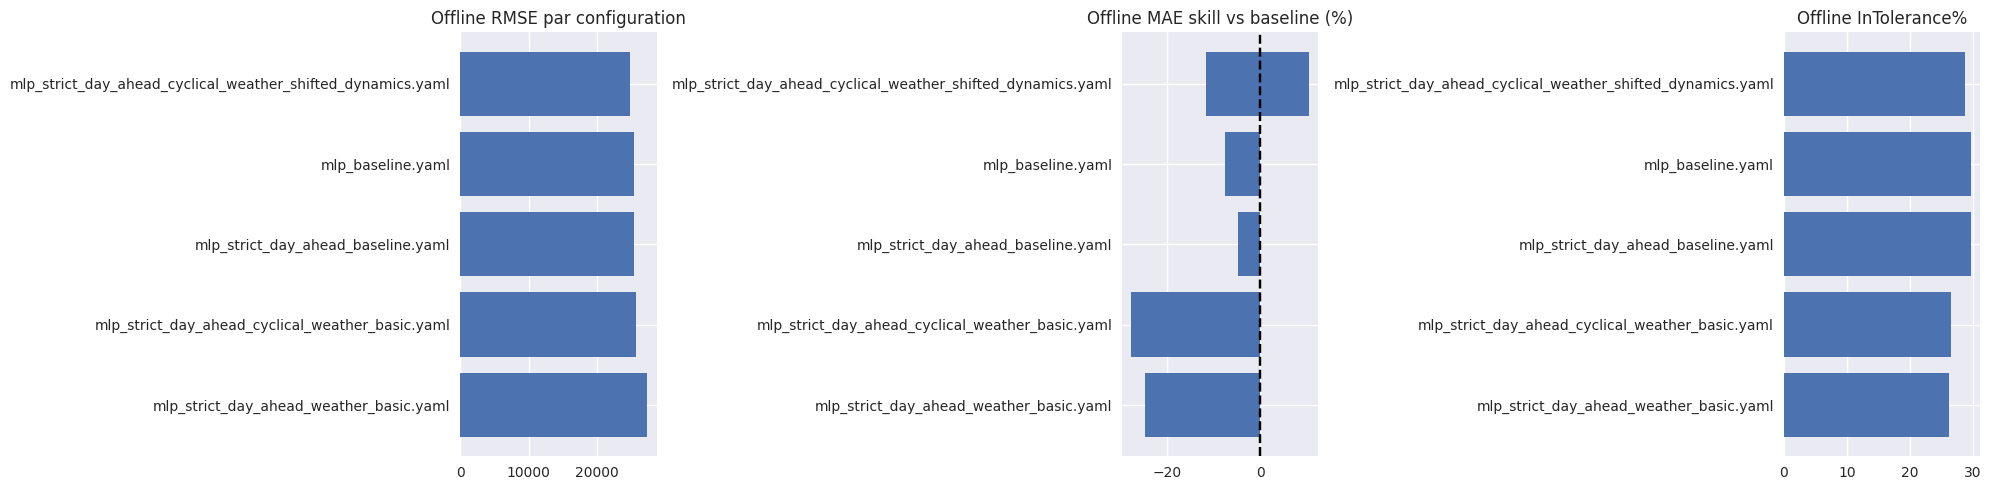

In [23]:
if not OFFLINE_BENCHMARK_DF.empty:
    plot_df = OFFLINE_BENCHMARK_DF.copy()
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes = axes.ravel()

    if 'RMSE' in plot_df.columns:
        axes[0].barh(plot_df['config_name'], plot_df['RMSE'])
        axes[0].set_title('Offline RMSE par configuration')
        axes[0].invert_yaxis()
    else:
        axes[0].set_axis_off()

    if 'MAE_skill_vs_baseline_%' in plot_df.columns:
        axes[1].barh(plot_df['config_name'], plot_df['MAE_skill_vs_baseline_%'])
        axes[1].set_title('Offline MAE skill vs baseline (%)')
        axes[1].axvline(0, linestyle='--', color='black')
        axes[1].invert_yaxis()
    else:
        axes[1].set_axis_off()

    if 'InTolerance%' in plot_df.columns:
        axes[2].barh(plot_df['config_name'], plot_df['InTolerance%'])
        axes[2].set_title('Offline InTolerance%')
        axes[2].invert_yaxis()
    else:
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

## 6. Replay benchmark officiel

Cette section :
- choisit une liste de runs à comparer,
- lance un replay multi-jours homogène,
- produit le leaderboard officiel.

In [24]:
replay_candidate_run_ids = []
if REPLAY_MODEL_RUN_IDS:
    replay_candidate_run_ids = [str(run_id) for run_id in REPLAY_MODEL_RUN_IDS]
else:
    replay_source = OFFLINE_BENCHMARK_DF.copy() if not OFFLINE_BENCHMARK_DF.empty else CATALOG_DF.copy()
    if OFFICIAL_ONLY_STRICT and 'forecast_mode' in replay_source.columns:
        replay_source = replay_source[replay_source['forecast_mode'].fillna('').astype(str) == 'strict_day_ahead'].copy()
    sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in replay_source.columns]
    replay_candidate_run_ids = replay_source.sort_values(sort_cols or ['run_id']).head(TOP_N_REPLAY_MODELS)['run_id'].astype(str).tolist()

REPLAY_MODEL_IDS_RESOLVED, REPLAY_EXCLUDED_MODEL_IDS = filter_strict_replay_run_ids(PROJECT_ROOT, replay_candidate_run_ids)
if REPLAY_EXCLUDED_MODEL_IDS:
    print('Replay: runs non strict exclus =', REPLAY_EXCLUDED_MODEL_IDS)
if RUN_REPLAY_BENCHMARK and replay_candidate_run_ids and not REPLAY_MODEL_IDS_RESOLVED:
    print('Replay: aucun run strict retenu apres filtrage.')

REFERENCE_RUN_FOR_REPLAY = REPLAY_MODEL_IDS_RESOLVED[0] if REPLAY_MODEL_IDS_RESOLVED else None

REPLAY_SUMMARY_CSV_RESOLVED = None
REPLAY_MANIFEST_JSON_RESOLVED = None
if RUN_REPLAY_BENCHMARK and REPLAY_MODEL_IDS_RESOLVED:
    REPLAY_SUMMARY_CSV_RESOLVED, REPLAY_MANIFEST_JSON_RESOLVED = run_replay_benchmark(PROJECT_ROOT, REPLAY_MODEL_IDS_RESOLVED, REFERENCE_RUN_FOR_REPLAY)
elif MANUAL_REPLAY_SUMMARY_CSV and resolve_existing_path(MANUAL_REPLAY_SUMMARY_CSV, PROJECT_ROOT):
    REPLAY_SUMMARY_CSV_RESOLVED = resolve_existing_path(MANUAL_REPLAY_SUMMARY_CSV, PROJECT_ROOT)
    REPLAY_MANIFEST_JSON_RESOLVED = resolve_existing_path(MANUAL_REPLAY_MANIFEST_JSON, PROJECT_ROOT) if MANUAL_REPLAY_MANIFEST_JSON else None

if REPLAY_SUMMARY_CSV_RESOLVED is not None and Path(REPLAY_SUMMARY_CSV_RESOLVED).exists():
    REPLAY_SUMMARY_DF, REPLAY_ALL_DF, REPLAY_PER_DAY_DF = load_replay_results(Path(REPLAY_SUMMARY_CSV_RESOLVED), CATALOG_DF)
    replay_sort_cols = [col for col in [REPLAY_SORT_METRIC, 'RMSE', 'MAE'] if col in REPLAY_SUMMARY_DF.columns]
    REPLAY_SUMMARY_DF = REPLAY_SUMMARY_DF.sort_values(replay_sort_cols or ['requested_model_run_id']).reset_index(drop=True)
else:
    REPLAY_SUMMARY_DF = pd.DataFrame()
    REPLAY_ALL_DF = pd.DataFrame()
    REPLAY_PER_DAY_DF = pd.DataFrame()

display_cols = [col for col in [
    'requested_model_run_id', 'config_name', 'forecast_mode', 'feature_signature',
    'MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'InTolerance%',
    'n_requested_days', 'n_forecasted_days', 'n_skipped_days'
] if col in REPLAY_SUMMARY_DF.columns]
display(REPLAY_SUMMARY_DF[display_cols] if not REPLAY_SUMMARY_DF.empty else pd.DataFrame())

> /home/khalid/cours/m1/SmartGrid_Project/smart-grid/.venv/bin/python /home/khalid/cours/m1/SmartGrid_Project/smart-grid/scripts/benchmark_replay_models.py --historical-csv '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/conso/Consumption data 2020-2026.csv' --start-date 2025-11-01 --end-date 2025-11-30 --artifacts-root /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts --device auto --weather-csv '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Weather data 2020-2026.csv' --holidays-xlsx /home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Holidays.xlsx consumption_mlp_20260416T030009Z consumption_mlp_20260416T025813Z consumption_mlp_20260416T033409Z consumption_mlp_20260416T033543Z consumption_mlp_20260416T035551Z
{
  "summary_csv": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/replay/20260419T192408Z__2025-11-01__2025-11-30/replay_benchmark_summary.csv",
  "manifest_json": "/home/khalid/cours/m1/S

,requested_model_run_id,feature_signature,MAE,RMSE,MAPE%,SMAPE%,InTolerance%,n_requested_days,n_forecasted_days,n_skipped_days
0,consumption_mlp_20260416T030009Z,cal | temp | lags | cyc | lagagg | shifted_dyn...,"19,219.886017","33,469.075107",7.503783,7.430531,33.773148,30,30,0
1,consumption_mlp_20260416T033409Z,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","35,222.070300",7.740588,7.690319,30.601852,30,30,0
2,consumption_mlp_20260416T033543Z,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","35,222.070300",7.740588,7.690319,30.601852,30,30,0
3,consumption_mlp_20260416T035551Z,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","35,222.070300",7.740588,7.690319,30.601852,30,30,0
4,consumption_mlp_20260416T025813Z,cal | temp | lags | J=7-1-2-3-4-5-6,"20,337.327760","35,168.473626",8.023143,7.818523,29.236111,30,30,0


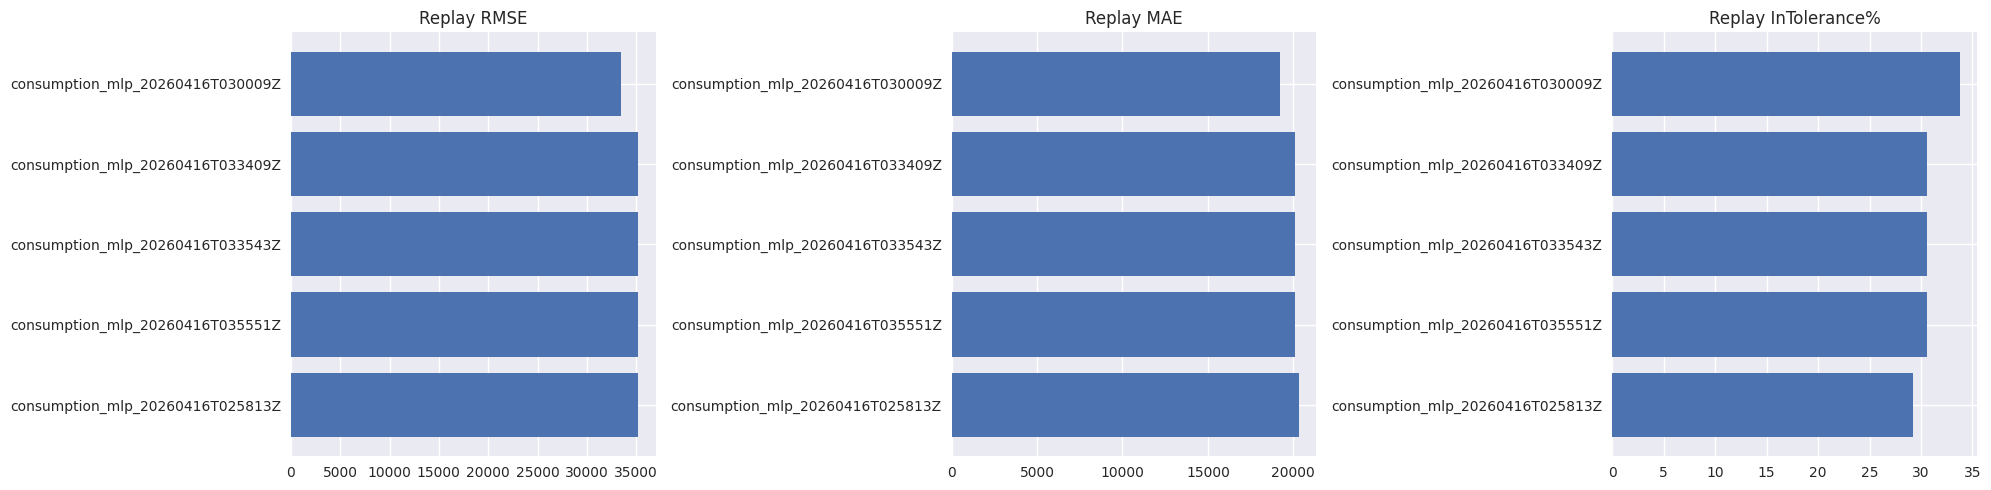

In [25]:
if SHOW_REPLAY_SUMMARY_PLOTS and not REPLAY_SUMMARY_DF.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes = axes.ravel()

    if 'RMSE' in REPLAY_SUMMARY_DF.columns:
        axes[0].barh(REPLAY_SUMMARY_DF['requested_model_run_id'], REPLAY_SUMMARY_DF['RMSE'])
        axes[0].set_title('Replay RMSE')
        axes[0].invert_yaxis()
    else:
        axes[0].set_axis_off()

    if 'MAE' in REPLAY_SUMMARY_DF.columns:
        axes[1].barh(REPLAY_SUMMARY_DF['requested_model_run_id'], REPLAY_SUMMARY_DF['MAE'])
        axes[1].set_title('Replay MAE')
        axes[1].invert_yaxis()
    else:
        axes[1].set_axis_off()

    if 'InTolerance%' in REPLAY_SUMMARY_DF.columns:
        axes[2].barh(REPLAY_SUMMARY_DF['requested_model_run_id'], REPLAY_SUMMARY_DF['InTolerance%'])
        axes[2].set_title('Replay InTolerance%')
        axes[2].invert_yaxis()
    else:
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

## 7. Sélection du run détaillé

Le run détaillé est par défaut :
1. le meilleur run du replay,
2. sinon le meilleur run offline,
3. sinon le run current.

In [26]:
SELECTED_RUN_ID_RESOLVED = resolve_selected_run_id(REPLAY_SUMMARY_DF, OFFLINE_BENCHMARK_DF, CURRENT_RUN_ID)
BASELINE_RUN_ID_RESOLVED = BASELINE_RUN_ID_RESOLVED if 'BASELINE_RUN_ID_RESOLVED' in globals() else resolve_baseline_run_id(OFFLINE_BENCHMARK_DF)

print('SELECTED_RUN_ID_RESOLVED =', SELECTED_RUN_ID_RESOLVED)
print('BASELINE_RUN_ID_RESOLVED =', BASELINE_RUN_ID_RESOLVED)

SELECTED_RUN_ID_RESOLVED = consumption_mlp_20260416T030009Z
BASELINE_RUN_ID_RESOLVED = consumption_mlp_20260416T025813Z


## 8. Analyse détaillée du run sélectionné

On charge :
- le summary,
- le backtest offline préparé,
- le jour d’analyse offline,
- puis on calcule les métriques et graphiques de base.

In [27]:
if not SELECTED_RUN_ID_RESOLVED:
    raise RuntimeError('Aucun run disponible pour l analyse detaillee.')

RUN_SUMMARY, OFFLINE_BACKTEST_DF, OFFLINE_DAY_DF = load_prepared_run_frames(
    PROJECT_ROOT,
    SELECTED_RUN_ID_RESOLVED,
    history_csv=HISTORICAL_CSV,
    requested_day=PROTOCOL_COMPARISON_DATE or FORECAST_TARGET_DATE,
)

summary_display = {k: v for k, v in RUN_SUMMARY.items() if not isinstance(v, (dict, list))}
display(pd.DataFrame({'key': list(summary_display.keys()), 'value': list(summary_display.values())}))

,key,value
0,run_id,consumption_mlp_20260416T030009Z
1,problem,consumption
2,experiment_name,consumption_mlp_strict_day_ahead_cyclical_weat...
3,backend,pytorch
4,device,cuda
5,dataset_key,full_2020_2026
6,dataset_description,Official consolidated 2020-2026 dataset for st...
7,catalog_path,/home/khalid/cours/m1/SmartGrid_Project/smart-...
8,date_col,Date
9,historical_csv,/home/khalid/cours/m1/SmartGrid_Project/smart-...


In [28]:
OFFLINE_COMPARISON_DF = pd.DataFrame()
if not OFFLINE_DAY_DF.empty:
    rows = []
    for label, col in [('MODEL', 'MODEL'), ('BASELINE_WEEKLY', 'BASELINE_WEEKLY'), ('OLD_LEGACY', 'OLD_LEGACY')]:
        if col in OFFLINE_DAY_DF.columns:
            row = {'series': label}
            row.update(compute_metrics(OFFLINE_DAY_DF['REAL'], OFFLINE_DAY_DF[col]))
            rows.append(row)
    OFFLINE_COMPARISON_DF = pd.DataFrame(rows)

display(OFFLINE_COMPARISON_DF)

,series,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,MODEL,144,"8,360.060833","11,623.579098","-6,536.548889",3.105857,3.174483,41.666667,"24,850.349500","37,619.759200",76.388889,23.611111,"9,750.508182","3,861.554706",0.486563,"7,234.312680"


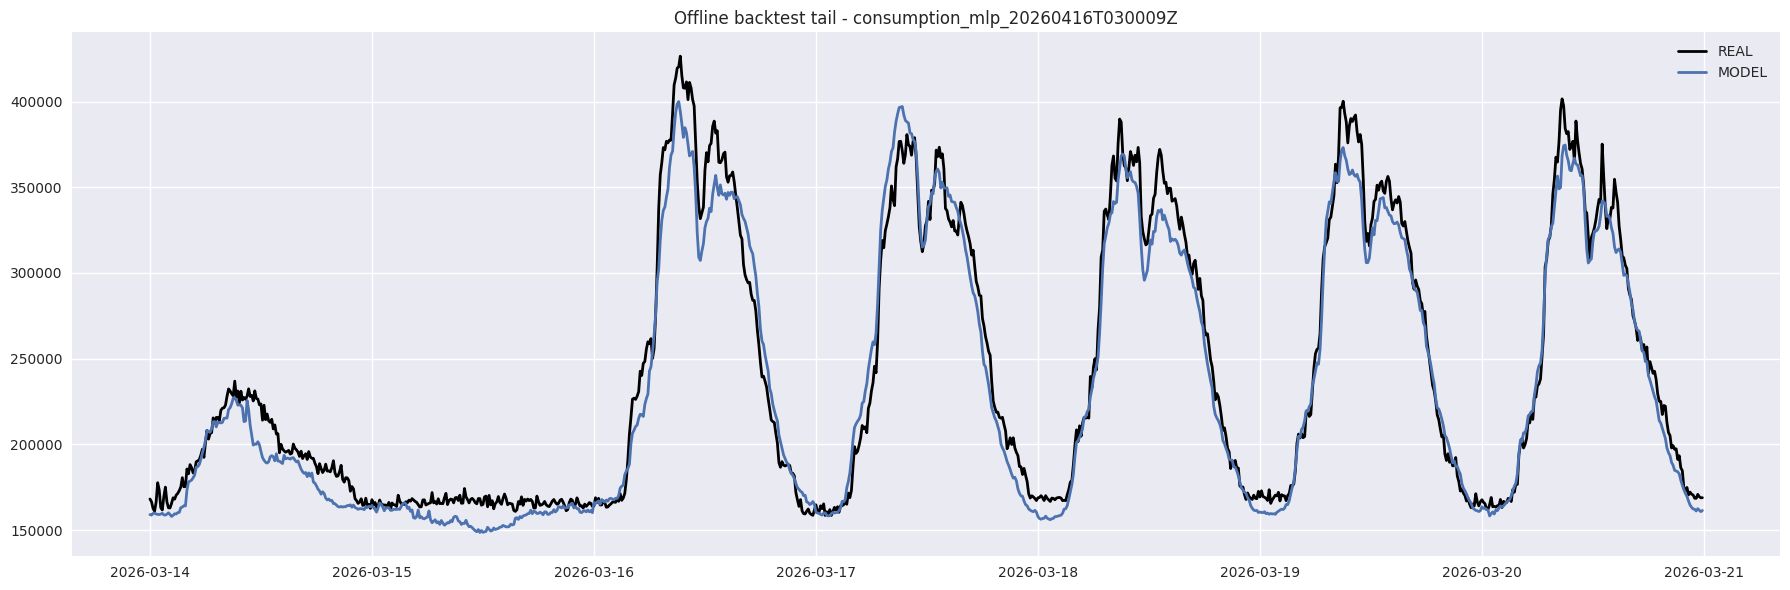

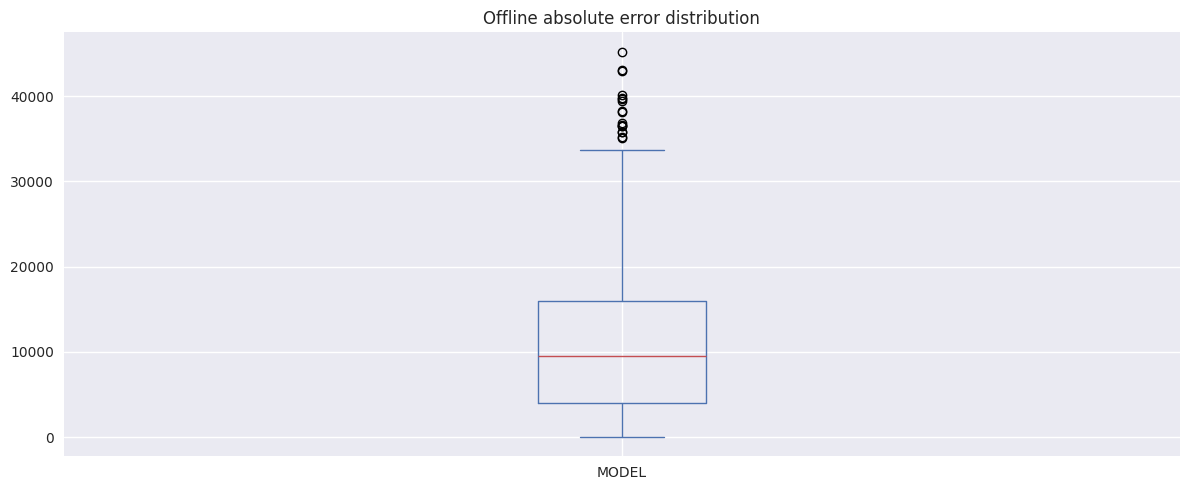

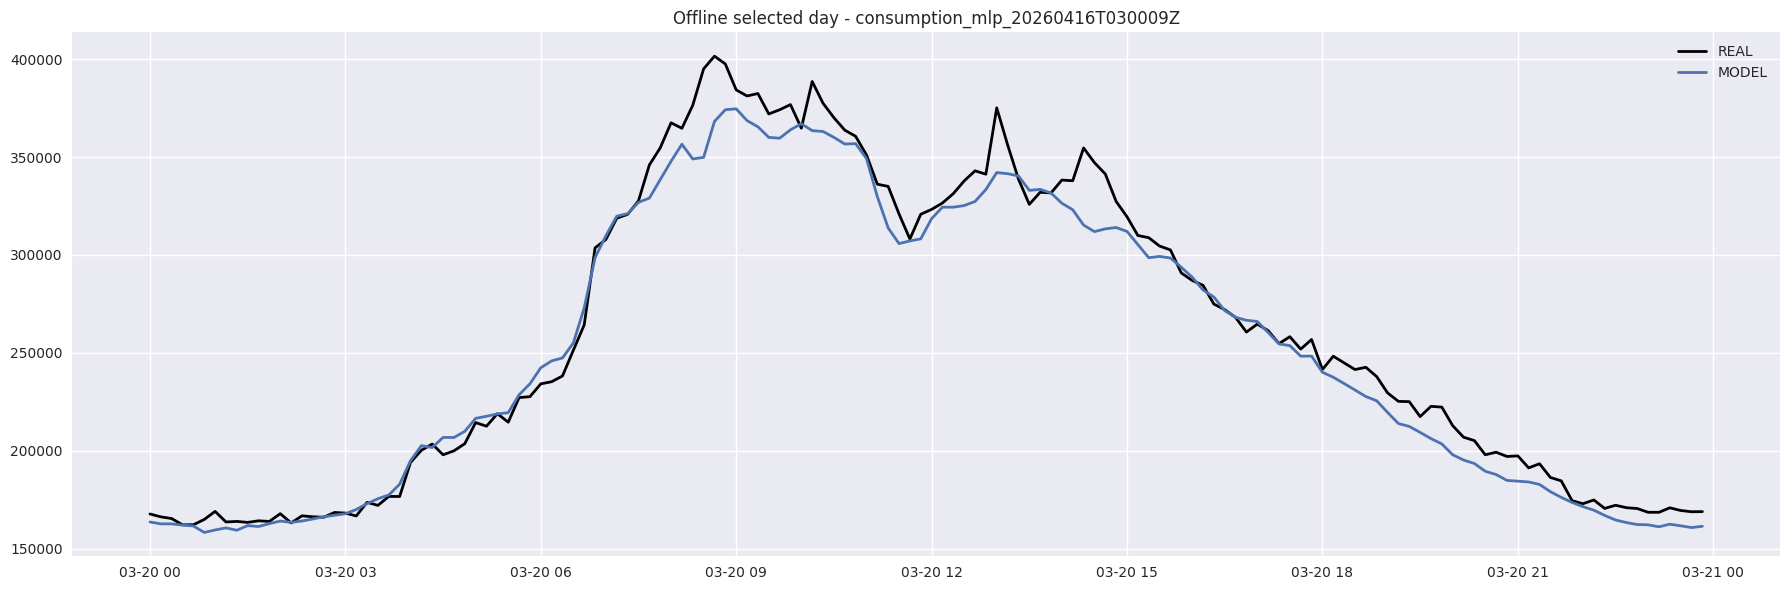

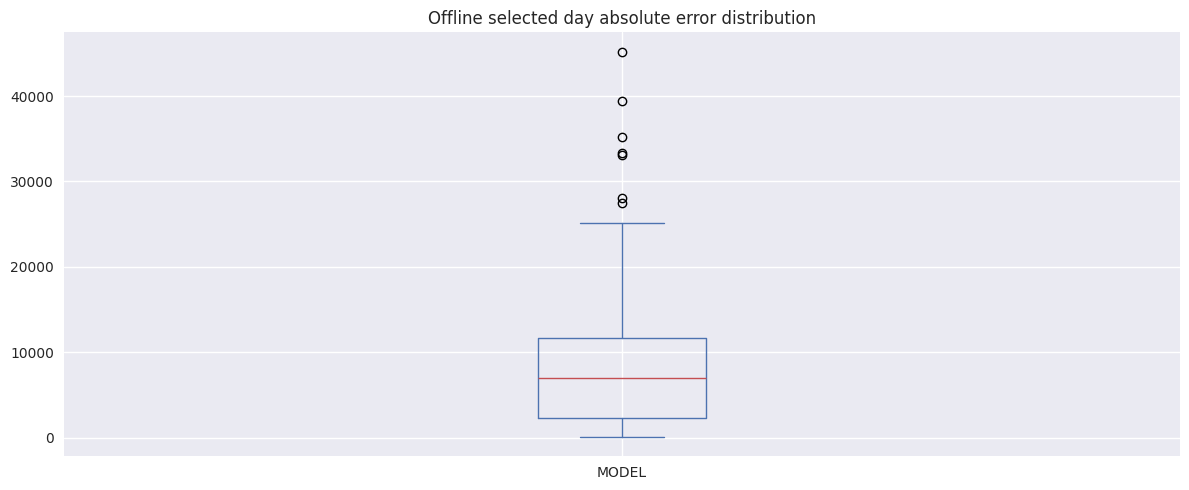

In [29]:
if SHOW_OFFLINE_TAIL and not OFFLINE_BACKTEST_DF.empty:
    tail_df = OFFLINE_BACKTEST_DF.copy()
    if len(tail_df) > PLOT_LAST_N_POINTS:
        tail_df = tail_df.iloc[-PLOT_LAST_N_POINTS:].copy()
    plot_day_curves(tail_df, f'Offline backtest tail - {SELECTED_RUN_ID_RESOLVED}')
    plot_error_box(tail_df, 'Offline absolute error distribution')

if not OFFLINE_DAY_DF.empty:
    plot_day_curves(OFFLINE_DAY_DF, f'Offline selected day - {SELECTED_RUN_ID_RESOLVED}')
    plot_error_box(OFFLINE_DAY_DF, 'Offline selected day absolute error distribution')

## 9. Predict target day

Cette section refait une vraie prédiction via la chaîne métier actuelle sur le run sélectionné.

In [30]:
PREDICT_TARGET_DATE_RESOLVED = normalize_date_str(FORECAST_TARGET_DATE) or normalize_date_str(PROTOCOL_COMPARISON_DATE) or normalize_date_str(RUN_SUMMARY.get('selected_analysis_day'))
PREDICT_DAY_DF = pd.DataFrame()

if SELECTED_RUN_ID_RESOLVED and PREDICT_TARGET_DATE_RESOLVED:
    PREDICT_DAY_DF = build_requested_day_frame(PROJECT_ROOT, SELECTED_RUN_ID_RESOLVED, PREDICT_TARGET_DATE_RESOLVED, history_csv=HISTORICAL_CSV)

print('PREDICT_TARGET_DATE_RESOLVED =', PREDICT_TARGET_DATE_RESOLVED)
display(PREDICT_DAY_DF.head())

PREDICT_TARGET_DATE_RESOLVED = 2026-03-20


,Date,MODEL,model_run_id,generated_at,target_date,dataset_key,forecast_mode,REAL
0,2026-03-20 00:00:00,"163,611.296875",consumption_mlp_20260416T030009Z,2026-04-19T19:25:31.206284+00:00,2026-03-20,full_2020_2026,strict_day_ahead,167696
1,2026-03-20 00:10:00,"162,661.921875",consumption_mlp_20260416T030009Z,2026-04-19T19:25:31.206284+00:00,2026-03-20,full_2020_2026,strict_day_ahead,166241
2,2026-03-20 00:20:00,"162,645.296875",consumption_mlp_20260416T030009Z,2026-04-19T19:25:31.206284+00:00,2026-03-20,full_2020_2026,strict_day_ahead,165365
3,2026-03-20 00:30:00,"162,036.875000",consumption_mlp_20260416T030009Z,2026-04-19T19:25:31.206284+00:00,2026-03-20,full_2020_2026,strict_day_ahead,162167
4,2026-03-20 00:40:00,"161,588.296875",consumption_mlp_20260416T030009Z,2026-04-19T19:25:31.206284+00:00,2026-03-20,full_2020_2026,strict_day_ahead,162210


,series,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,MODEL,144,"8,360.060655","11,623.579512","-6,536.548937",3.105856,3.174483,41.666667,"24,850.348437","37,619.754375",76.388889,23.611111,"9,750.508097","3,861.554228",0.486563,"7,234.310555"


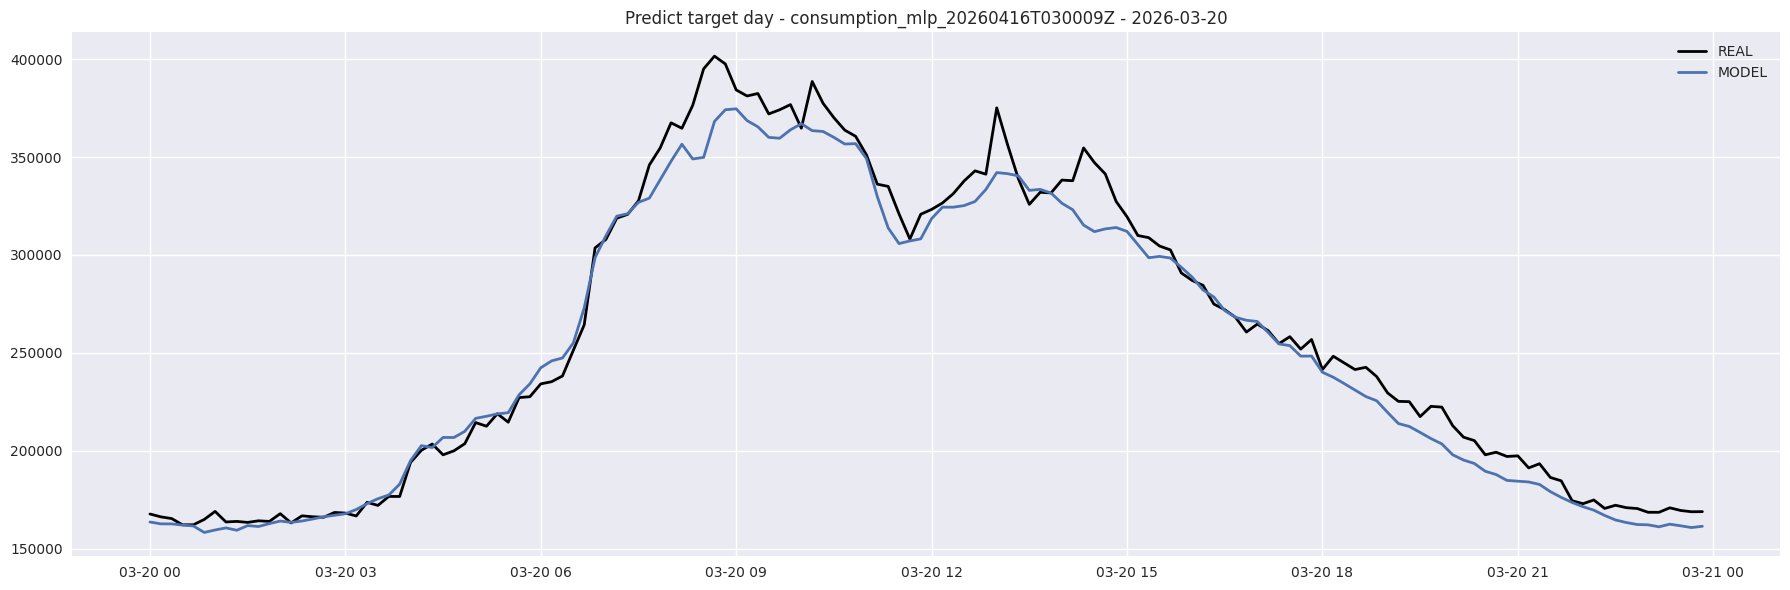

In [31]:
if not PREDICT_DAY_DF.empty:
    predict_metrics_rows = []
    for label, col in [('MODEL', 'MODEL'), ('BASELINE_WEEKLY', 'BASELINE_WEEKLY'), ('OLD_LEGACY', 'OLD_LEGACY')]:
        if col in PREDICT_DAY_DF.columns:
            row = {'series': label}
            row.update(compute_metrics(PREDICT_DAY_DF['REAL'], PREDICT_DAY_DF[col]))
            predict_metrics_rows.append(row)
    PREDICT_METRICS_DF = pd.DataFrame(predict_metrics_rows)
    display(PREDICT_METRICS_DF)
    plot_day_curves(PREDICT_DAY_DF, f'Predict target day - {SELECTED_RUN_ID_RESOLVED} - {PREDICT_TARGET_DATE_RESOLVED}')
else:
    print('Aucune prediction disponible.')

## 10. Replay same-day

On extrait la même date depuis le replay officiel pour comparer exactement les protocoles.

In [32]:
REPLAY_DAY_DF = pd.DataFrame()
if not REPLAY_ALL_DF.empty and SELECTED_RUN_ID_RESOLVED and PREDICT_TARGET_DATE_RESOLVED:
    REPLAY_DAY_DF = build_replay_requested_day_frame(REPLAY_ALL_DF, SELECTED_RUN_ID_RESOLVED, PREDICT_TARGET_DATE_RESOLVED, history_csv=HISTORICAL_CSV)

display(REPLAY_DAY_DF.head())

""


In [33]:
if not REPLAY_DAY_DF.empty:
    replay_metrics_rows = []
    for label, col in [('MODEL', 'MODEL'), ('BASELINE_WEEKLY', 'BASELINE_WEEKLY'), ('OLD_LEGACY', 'OLD_LEGACY')]:
        if col in REPLAY_DAY_DF.columns:
            row = {'series': label}
            row.update(compute_metrics(REPLAY_DAY_DF['REAL'], REPLAY_DAY_DF[col]))
            replay_metrics_rows.append(row)
    REPLAY_DAY_METRICS_DF = pd.DataFrame(replay_metrics_rows)
    display(REPLAY_DAY_METRICS_DF)
    plot_day_curves(REPLAY_DAY_DF, f'Replay same day - {SELECTED_RUN_ID_RESOLVED} - {PREDICT_TARGET_DATE_RESOLVED}')
else:
    print('Aucun replay same-day disponible.')

Aucun replay same-day disponible.


## 11. Comparaison de protocoles sur la même date

Ici, on compare explicitement :
- `benchmark_test_day` (offline diagnostic),
- `predict_target_day` (chaîne métier),
- `replay_same_day` (chaîne métier rejouée).

In [34]:
PROTOCOL_COMPARISON_RUN_ID_RESOLVED = str(PROTOCOL_COMPARISON_RUN_ID or SELECTED_RUN_ID_RESOLVED) if (PROTOCOL_COMPARISON_RUN_ID or SELECTED_RUN_ID_RESOLVED) else None
PROTOCOL_COMPARISON_TARGET_DATE = normalize_date_str(PROTOCOL_COMPARISON_DATE) or PREDICT_TARGET_DATE_RESOLVED

protocol_frames = {
    'benchmark_test_day': prepare_protocol_frame(OFFLINE_DAY_DF, 'benchmark_test_day', PROTOCOL_COMPARISON_TARGET_DATE, PROTOCOL_COMPARISON_RUN_ID_RESOLVED) if not OFFLINE_DAY_DF.empty else pd.DataFrame(),
    'predict_target_day': prepare_protocol_frame(PREDICT_DAY_DF, 'predict_target_day', PROTOCOL_COMPARISON_TARGET_DATE, PROTOCOL_COMPARISON_RUN_ID_RESOLVED) if not PREDICT_DAY_DF.empty else pd.DataFrame(),
    'replay_same_day': prepare_protocol_frame(REPLAY_DAY_DF, 'replay_same_day', PROTOCOL_COMPARISON_TARGET_DATE, PROTOCOL_COMPARISON_RUN_ID_RESOLVED) if not REPLAY_DAY_DF.empty else pd.DataFrame(),
}

PROTOCOL_METRICS_DF = summarize_protocol_metrics(protocol_frames)
PROTOCOL_COMPARE_DF, PROTOCOL_DELTA_DF = compare_protocol_predictions(protocol_frames)

display(PROTOCOL_METRICS_DF)
display(PROTOCOL_DELTA_DF)

,protocol,target_date,run_id,effective_model_run_ids,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,benchmark_test_day,2026-03-20,consumption_mlp_20260416T030009Z,consumption_mlp_20260416T030009Z,144,"8,360.060833","11,623.579098","-6,536.548889",3.105857,3.174483,41.666667,"24,850.349500","37,619.759200",76.388889,23.611111,"9,750.508182","3,861.554706",0.486563,"7,234.312680"
1,predict_target_day,2026-03-20,consumption_mlp_20260416T030009Z,consumption_mlp_20260416T030009Z,144,"8,360.060655","11,623.579512","-6,536.548937",3.105856,3.174483,41.666667,"24,850.348437","37,619.754375",76.388889,23.611111,"9,750.508097","3,861.554228",0.486563,"7,234.310555"


,reference_protocol,compared_protocol,overlap_count,mean_abs_prediction_delta,max_abs_prediction_delta
0,benchmark_test_day,predict_target_day,144,0.011072,0.050625


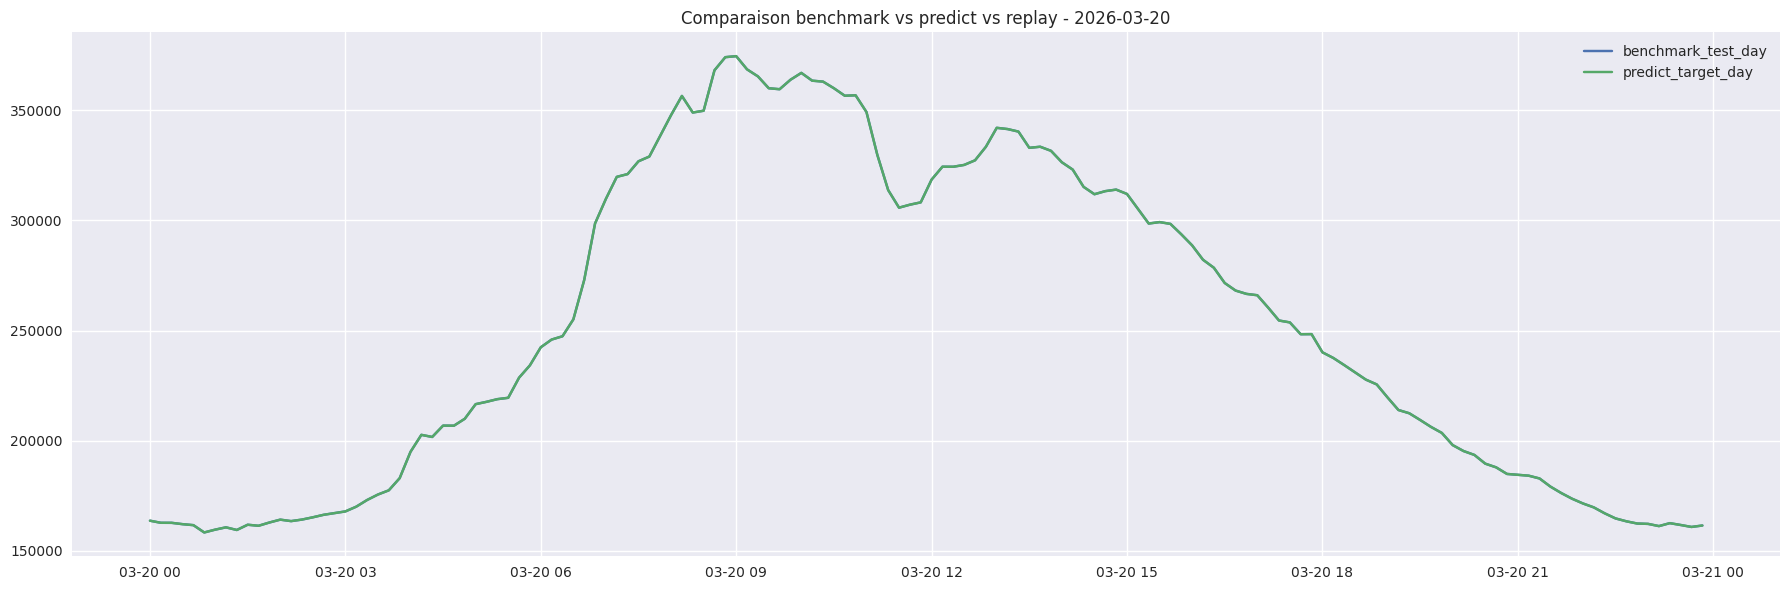

In [35]:
if not PROTOCOL_COMPARE_DF.empty:
    plt.figure(figsize=(18, 6))
    for col in [c for c in PROTOCOL_COMPARE_DF.columns if c != 'Date']:
        plt.plot(PROTOCOL_COMPARE_DF['Date'], PROTOCOL_COMPARE_DF[col], label=col)
    plt.title(f'Comparaison benchmark vs predict vs replay - {PROTOCOL_COMPARISON_TARGET_DATE}')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 12. Classement final global

Le classement final est **replay-first** :
- si le replay existe, il porte la vérité métier,
- l'offline reste affiché à côté comme signal diagnostic.

In [36]:
FINAL_LEADERBOARD_DF = pd.DataFrame()

if not REPLAY_SUMMARY_DF.empty:
    FINAL_LEADERBOARD_DF = REPLAY_SUMMARY_DF.rename(columns={'requested_model_run_id': 'run_id'}).copy()
    offline_keep = [col for col in ['run_id', 'config_name', 'feature_signature', 'forecast_mode', 'MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'InTolerance%'] if col in OFFLINE_BENCHMARK_DF.columns]
    if offline_keep:
        offline_meta = OFFLINE_BENCHMARK_DF[offline_keep].drop_duplicates(subset=['run_id']).rename(columns={
            'MAE': 'offline_MAE',
            'RMSE': 'offline_RMSE',
            'MAPE%': 'offline_MAPE%',
            'SMAPE%': 'offline_SMAPE%',
            'InTolerance%': 'offline_InTolerance%',
        })
        FINAL_LEADERBOARD_DF = FINAL_LEADERBOARD_DF.merge(offline_meta, on='run_id', how='left', suffixes=('', '_offline_meta'))
    FINAL_LEADERBOARD_DF['official_rank_metric'] = FINAL_LEADERBOARD_DF[REPLAY_SORT_METRIC] if REPLAY_SORT_METRIC in FINAL_LEADERBOARD_DF.columns else np.nan
    sort_cols = [col for col in ['official_rank_metric', 'RMSE', 'MAE'] if col in FINAL_LEADERBOARD_DF.columns]
    FINAL_LEADERBOARD_DF = FINAL_LEADERBOARD_DF.sort_values(sort_cols or ['run_id']).reset_index(drop=True)
else:
    FINAL_LEADERBOARD_DF = OFFLINE_BENCHMARK_DF.copy()
    FINAL_LEADERBOARD_DF['official_rank_metric'] = FINAL_LEADERBOARD_DF[PREFERRED_SORT_METRIC] if PREFERRED_SORT_METRIC in FINAL_LEADERBOARD_DF.columns else np.nan

display_cols = [col for col in [
    'run_id', 'config_name', 'forecast_mode', 'feature_signature',
    'official_rank_metric', 'MAE', 'RMSE', 'InTolerance%',
    'offline_MAE', 'offline_RMSE', 'offline_InTolerance%',
    'n_requested_days', 'n_forecasted_days', 'n_skipped_days'
] if col in FINAL_LEADERBOARD_DF.columns]
display(FINAL_LEADERBOARD_DF[display_cols])

,run_id,config_name,forecast_mode,feature_signature,official_rank_metric,MAE,RMSE,InTolerance%,offline_MAE,offline_RMSE,offline_InTolerance%,n_requested_days,n_forecasted_days,n_skipped_days
0,consumption_mlp_20260416T030009Z,mlp_strict_day_ahead_cyclical_weather_shifted_...,strict_day_ahead,cal | temp | lags | cyc | lagagg | shifted_dyn...,"19,219.886017","19,219.886017","33,469.075107",33.773148,"12,608.113645","17,815.831899",28.691727,30,30,0
1,consumption_mlp_20260416T033409Z,mlp_baseline.yaml,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","20,107.979986","35,222.070300",30.601852,"14,674.984567","24,296.989980",28.808495,30,30,0
2,consumption_mlp_20260416T033543Z,mlp_strict_day_ahead_baseline.yaml,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","20,107.979986","35,222.070300",30.601852,"14,674.984567","24,296.989980",28.808495,30,30,0
3,consumption_mlp_20260416T035551Z,mlp_baseline.yaml,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"20,107.979986","20,107.979986","35,222.070300",30.601852,"14,674.984567","24,296.989980",28.808495,30,30,0
4,consumption_mlp_20260416T025813Z,mlp_baseline.yaml,strict_day_ahead,cal | temp | lags | J=7-1-2-3-4-5-6,"20,337.327760","20,337.327760","35,168.473626",29.236111,"14,082.716425","19,899.129638",25.523049,30,30,0


## 13. Notes d'interprétation

- Si `predict_target_day` et `replay_same_day` divergent fortement, il reste une non-parité de pipeline à investiguer.
- Si `predict_target_day` et `replay_same_day` collent, mais que les métriques restent mauvaises, le prochain chantier est **modèle/features**, pas benchmark.
- Le notebook V2 doit rester **simple** :
  - offline pour diagnostiquer,
  - replay pour décider,
  - predict / replay same-day pour valider la chaîne métier,
  - quelques graphes lisibles pour comprendre.